In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
excel_file = 'cleaned_dataset_ MohammadRezaei5.xlsx'
df = pd.read_excel(excel_file)

m_med = df['total_spending'].median()
f_med = df['purchase_count'].median()
r_med = df['last_purchase_days'].median()

print("Medians:", f"Monetary: {m_med:.2f}, Frequency: {f_med:.2f}, Recency: {r_med:.2f}")

def assign_segment(row):
    recent = row['last_purchase_days'] < 180
    high_spending = row['total_spending'] >= m_med
    high_freq = row['purchase_count'] >= f_med
    
    if recent and high_spending:
        return 'Champions'
    elif recent and not high_spending:
        return 'Promising / Potential'
    elif not recent and high_spending:
        return 'At Risk'
    else:
        return 'Needs Attention'

df['segment'] = df.apply(assign_segment, axis=1)

segment_summary = df.groupby('segment').agg(
    customer_count=('customer_id', 'count'),
    avg_spending=('total_spending', 'mean'),
    total_spending_sum=('total_spending', 'sum'),
    avg_purchase_count=('purchase_count', 'mean'),
    avg_recency=('last_purchase_days', 'mean'),
    avg_satisfaction=('satisfaction_score', 'mean')
).reset_index()

print(segment_summary.to_string())

Medians: Monetary: 2128.69, Frequency: 17.00, Recency: 203.00
                 segment  customer_count  avg_spending  total_spending_sum  avg_purchase_count  avg_recency  avg_satisfaction
0                At Risk              19   5471.855263           103965.25           22.263158   261.210526          2.736842
1              Champions              11   5754.483636            63299.32           23.727273    98.090909          3.454545
2        Needs Attention              17   1027.447647            17466.61           10.235294   268.058824          2.529412
3  Promising / Potential              13   1327.273077            17254.55           14.230769   101.307692          3.538462


In [3]:
def assign_4_segments(row):
    recent = row['last_purchase_days'] < 180
    high_spending = row['total_spending'] >= m_med # $2,128.69
    
    if recent and high_spending:
        return 'Champions'
    elif recent and not high_spending:
        return 'Loyal Customers' # Or Active/New/Potential
    elif not recent and high_spending:
        return 'At Risk'
    else:
        return 'Needs Attention'

df['segment'] = df.apply(assign_4_segments, axis=1)

summary = df.groupby('segment').agg(
    count=('customer_id', 'count'),
    avg_spending=('total_spending', 'mean'),
    avg_purchases=('purchase_count', 'mean'),
    avg_recency=('last_purchase_days', 'mean'),
    avg_satisfaction=('satisfaction_score', 'mean')
).reset_index()

print(summary)

           segment  count  avg_spending  avg_purchases  avg_recency  \
0          At Risk     19   5471.855263      22.263158   261.210526   
1        Champions     11   5754.483636      23.727273    98.090909   
2  Loyal Customers     13   1327.273077      14.230769   101.307692   
3  Needs Attention     17   1027.447647      10.235294   268.058824   

   avg_satisfaction  
0          2.736842  
1          3.454545  
2          3.538462  
3          2.529412  


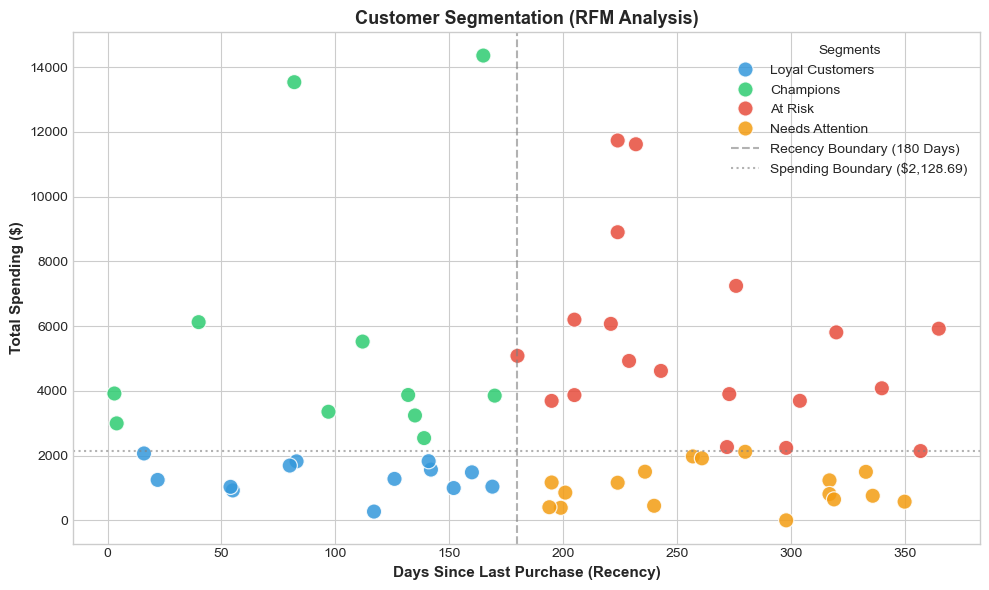

In [5]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 6))

colors = {'Champions': '#2ecc71', 'Loyal Customers': '#3498db', 'At Risk': '#e74c3c', 'Needs Attention': '#f39c12'}

sns.scatterplot(
    data=df,
    x='last_purchase_days',
    y='total_spending',
    hue='segment',
    palette=colors,
    s=120,
    alpha=0.85,
    ax=ax
)

ax.axvline(180, color='gray', linestyle='--', alpha=0.6, label='Recency Boundary (180 Days)')
ax.axhline(m_med, color='gray', linestyle=':', alpha=0.6, label=f'Spending Boundary (${m_med:,.2f})')

ax.set_title('Customer Segmentation (RFM Analysis)', fontsize=13, fontweight='bold')
ax.set_xlabel('Days Since Last Purchase (Recency)', fontsize=11, fontweight='bold')
ax.set_ylabel('Total Spending ($)', fontsize=11, fontweight='bold')
ax.legend(title='Segments', title_fontsize='10', loc='upper right')

plt.tight_layout()
plt.show()
plt.close()